<a href="https://colab.research.google.com/github/EdvanylsonAssuncao/curso_IA_generativa/blob/main/opencv_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# --- LEITURA AUTOMÁTICA DE PLACAS (OpenCV + OCR) ---
!pip install easyocr opencv-python
import cv2
import easyocr
from google.colab.patches import cv2_imshow

  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 18.1 MB/s eta 0:00:00


[SISTEMA] Escaneando caracteres da placa ...

[SUCESSO] Texto extraído pela IA: BRA2E19

--- Recorte focado enviado para a IA ---


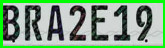


--- Resultado do Sistema de Monitoramento ---


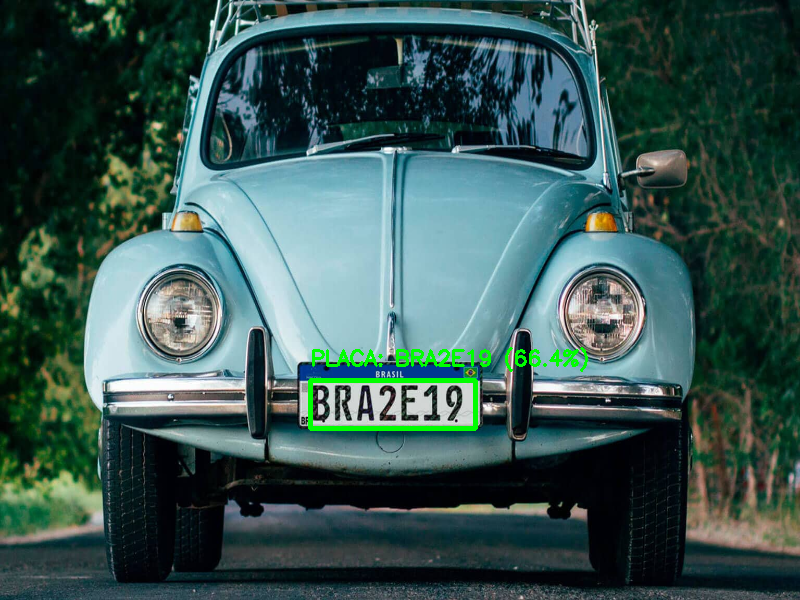

In [54]:
# 1. Inicializar o leitor de OCR da IA para o idioma português
leitor_ocr = easyocr.Reader(['pt'])

#2. Carregar a imagem do veículo e redimensionar para manter um padrão
imagem_veiculo = cv2.imread('carro.jpg')
imagem_veiculo = cv2.resize(imagem_veiculo, (800, 600))

# 3. Converter para escala de cinza
imagem_cinza = cv2.cvtColor(imagem_veiculo, cv2.COLOR_BGR2GRAY)

# Coordenadas
x_ini, x_fim = 310, 475
y_ini, y_fim = 380, 428

placa_recortada_cinza = imagem_cinza[y_ini:y_fim, x_ini:x_fim]
placa_recortada_colorida = imagem_veiculo[y_ini:y_fim, x_ini:x_fim]

# 4. Passar o recorte no leitor de OCR para extrair as letras
print("[SISTEMA] Escaneando caracteres da placa ...")
resultados_ocr = leitor_ocr.readtext(placa_recortada_cinza)

# 5. Extrair o texto encontrado se a IA conseguir ler algo
if len(resultados_ocr) > 0:
    texto_placa = resultados_ocr[0][1].upper().replace(" ", "")
    confianca = resultados_ocr[0][2] * 100

    # 6. Usar o OpenCV para desenhar o resultado na imagem
    cv2.rectangle(
        imagem_veiculo, (x_ini, y_ini), (x_fim, y_fim), (0, 255, 0), 3
        )
    cv2.putText(
        imagem_veiculo, f"PLACA: {texto_placa} ({confianca:.1f}%)",
        (x_ini, y_ini -15), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2
    )

    print(f"\n[SUCESSO] Texto extraído pela IA: {texto_placa}")
else:
    print("\n[ALERTA] Não foi possível decifrar os caracteres.")
    texto_placa = "NÃO DETECTADA"

# 7. Exibir o painel visual final para validação
print("\n--- Recorte focado enviado para a IA ---")
cv2_imshow(placa_recortada_colorida)

print("\n--- Resultado do Sistema de Monitoramento ---")
cv2_imshow(imagem_veiculo)